# FINAL Step 2.3 — Supporting Extension Experiments

A **self-contained** consolidation of the *non-region-aware* extension experiments tried beyond the paper-style
replication. It sits between the replication notebooks (FINAL 2.1 tissue, FINAL 2.2 mass) and the region-aware
deep-dive (**FINAL Step 2.4**), and its job is to show *what else we tried* — generic changes to the WS
representation, the classifier, the CNN crop, and feature fusion — and that these gave **useful but limited**
gains, which is what motivated the dedicated region-aware investigation in FINAL 2.4.

**Self-contained & recomputed.** Everything is recomputed here from stable preprocessing artefacts only
(`background_patches/patches_index.csv`, `masses/mass_index.csv`, `preprocessed/final/*.npy`). It does **not**
read any old experimental result caches (`ws_v1`, `ws_v2_codex`, `scov_v1`, `cnn_v1`, `consolidated_eval`, …).
Expensive intermediates (WS tensors, scattering-covariance features, frozen-CNN features) are cached **only**
under this notebook's own folder `data/outputs/final_step2_3_supporting_extensions/`, so a first run is slow but
re-runs are fast — these are generated by *this* notebook, not inherited.

**Region-aware methods are out of scope here** — the region-aware WS, the WS-map CNN head, the region ablation,
and region-aware fusion all live in *FINAL Step 2.4 — Mass Classification: Region-Aware Extensions*. Where this
notebook touches a precursor (the full-patch WS→CNN head), it is clearly marked as a precursor and not duplicated.

**Evaluation philosophy (same lock as the FINAL notebooks).** Image-level / group-aware splits (grouped by
`file_id`); repeated **5-seed** holdout `[1, 7, 34, 42, 99]`; **AUROC-led** for the imbalanced mass task; all
scalers / PCA / feature-selection / classifiers fit on the **training fold only** (inside a `Pipeline`), so no
test information leaks into preprocessing or model selection; held-out results are kept distinct from CV.

## 1. Setup, reproducibility, and paths

In [1]:
import os, sys, time, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torchvision
from torch.utils.data import DataLoader, TensorDataset
from kymatio.scattering2d.frontend.numpy_frontend import ScatteringNumPy2D as Scattering2D
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
warnings.filterwarnings("ignore")

# --- bootstrap: make the shared project34 package importable, then load the locked protocol ---
from pathlib import Path as _P
_r = _P.cwd().resolve()
while not (_r / 'project34' / '__init__.py').exists() and _r != _r.parent: _r = _r.parent
if str(_r) not in sys.path: sys.path.insert(0, str(_r))
from project34.protocol import (set_seed, find_project_root, SEEDS, SubspaceKNN,
                                sknn_pipe, logreg_pipe, svm_pipe, image_split,
                                holdout5, cv_seed34, show)



ROOT = find_project_root()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SCOV_DEVICE = "gpu" if torch.cuda.is_available() else "cpu"   # Cheng package uses 'gpu'/'cpu'
torch.set_num_threads(os.cpu_count() or 4)
PATCH_SHAPE = (224, 224)

TISSUE_INDEX = ROOT/"data"/"outputs"/"background_patches"/"patches_index.csv"
MASS_INDEX   = ROOT/"data"/"outputs"/"masses"/"mass_index.csv"
PREPROC      = ROOT/"data"/"outputs"/"preprocessed"/"final"
OUT = ROOT/"data"/"outputs"/"final_step2_3_supporting_extensions"; OUT.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT); print("device:", DEVICE, "| scov device:", SCOV_DEVICE)
print("inputs present:", TISSUE_INDEX.exists(), MASS_INDEX.exists(), PREPROC.exists())
print("own output dir:", OUT)
ROWS = []   # consolidated results collector

ROOT: /home/nabeel/project34/Project34
device: cpu | scov device: cpu
inputs present: True True True
own output dir: /home/nabeel/project34/Project34/data/outputs/final_step2_3_supporting_extensions


## 2. Data loading (self-contained)

Tissue background patches are loaded from the Step 1.3 manifest; mass ROI patches are **rebuilt** from the Step 1.2
bounding boxes cropped out of the Step 1.1 preprocessed images (same recipe as FINAL 2.2), with the one all-zero
patch dropped. Labels and `file_id` groups are recreated exactly as in the FINAL replication notebooks.

*(Count reconciliation: 116 Mass ROIs across **107** annotated images → after dropping the single all-zero patch,
**115 patches across 106 images**. The missing image is `file_id 50994354`, whose only Mass ROI falls entirely
outside the breast mask — see the data-quality note in CLAUDE.md / report §4.6.)*

In [2]:
def resolve(p):
    s = str(p).replace("\\", "/"); i = s.find("data/outputs/")
    return (ROOT/s[i:]) if i >= 0 else Path(s)

def load01(p):
    a = np.load(p).astype(np.float32); a = np.nan_to_num(a, nan=0., posinf=1., neginf=0.)
    return np.clip(a, 0., 1.)

# ---- tissue (fatty vs fibroglandular) ----
tdf = pd.read_csv(TISSUE_INDEX)
tdf = tdf[tdf["label"].isin(["fatty", "fibroglandular"])].copy()
tdf["patch_npy"] = tdf["patch_npy"].apply(resolve)
tdf = tdf[tdf["patch_npy"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
tdf["class_id"] = tdf["label"].map({"fatty": 0, "fibroglandular": 1})
t_y = tdf["class_id"].to_numpy(np.int64); t_g = tdf["file_id"].to_numpy()
t_strat = tdf.groupby("file_id")["acr"].first()   # image-level stratify key (ACR density)
print("TISSUE: %d patches  %s  | %d images | ACR/img: %s" % (
    len(tdf), tdf["label"].value_counts().to_dict(), tdf["file_id"].nunique(),
    t_strat.value_counts().sort_index().to_dict()))

# ---- mass (benign vs malignant), rebuilt from mass_index + preprocessed ----
import cv2
def birads_to_label(b):
    s = str(b).strip()
    if s == "1": return None
    return "benign" if s in {"2", "3"} else "malignant"
pre_index = {p.name.split("_", 1)[0]: p for p in PREPROC.glob("*.npy")}
mrec, skipped = [], 0
mass_raw = pd.read_csv(MASS_INDEX)
for r in mass_raw.itertuples(index=False):
    lab = birads_to_label(r.birads)
    if lab is None: skipped += 1; continue
    fid = str(r.file_id); pre = pre_index.get(fid)
    if pre is None: skipped += 1; continue
    img = np.load(pre).astype(np.float32); H, W = img.shape
    y0, y1 = max(0, int(r.y0)), min(H, int(r.y1)); x0, x1 = max(0, int(r.x0)), min(W, int(r.x1))
    if y1-y0 < 2 or x1-x0 < 2: skipped += 1; continue
    patch = cv2.resize(img[y0:y1, x0:x1], (224, 224), interpolation=cv2.INTER_AREA)
    mrec.append(dict(file_id=fid, roi_index=int(r.roi_index), label=lab,
                     class_id=0 if lab == "benign" else 1, birads=str(r.birads),
                     y0=int(r.y0), y1=int(r.y1), x0=int(r.x0), x1=int(r.x1),
                     preproc_path=str(pre), patch=np.clip(patch, 0, 1).astype(np.float32)))
mdf = pd.DataFrame(mrec)
_before = len(mdf)
mdf = mdf[mdf["patch"].apply(lambda a: float(a.max()) > 0)].reset_index(drop=True)   # drop all-zero patch
m_y = mdf["class_id"].to_numpy(np.int64); m_g = mdf["file_id"].to_numpy()
m_strat = mdf.groupby("file_id")["label"].agg(lambda s: s.value_counts().idxmax())   # majority label/img
print("MASS  : %d patches (dropped %d zero, skipped %d)  %s  | %d images" % (
    len(mdf), _before-len(mdf), skipped, mdf["label"].value_counts().to_dict(), mdf["file_id"].nunique()))

TISSUE: 434 patches  {'fatty': 251, 'fibroglandular': 183}  | 100 images | ACR/img: {1: 36, 2: 35, 3: 21, 4: 8}


MASS  : 115 patches (dropped 1 zero, skipped 0)  {'malignant': 74, 'benign': 41}  | 106 images


## 3. Shared evaluation utilities

The Subspace k-NN ensemble (the paper's classifier), the image-level split, the **5-seed holdout** driver, a
single-seed group-CV helper, and small table/plot helpers. The holdout driver takes an estimator **factory** that
returns a fresh `Pipeline` each seed, so every scaler / PCA / selector / classifier is fit on that split's
**training fold only**.

In [3]:
# SubspaceKNN, sknn_pipe, image_split, holdout5, cv_seed34, show are imported from
# project34.protocol (above). `record` stays local (notebook-specific column schema).





def record(method, task, res, role, reason, cv=None):
    d = dict(method=method, task=task, auroc=res["auroc"], auroc_sd=res["auroc_sd"],
             test_acc=res["acc"], test_acc_sd=res["acc_sd"], f1=res["f1"], role=role, reason=reason)
    if cv is not None: d["cv_seed34"] = cv
    ROWS.append(d); return d


MAJ = {}
for task, y, g, st in [("tissue", t_y, t_g, t_strat), ("mass", m_y, m_g, m_strat)]:
    r = holdout5(np.zeros((len(y),1)), y, g, st, lambda s: DummyClassifier(strategy="most_frequent"))
    MAJ[task] = r; show("Majority baseline ("+task+")", r)
    record("Majority baseline", task, r, "baseline", "trivial reference")

  Majority baseline (tissue)                   AUROC 0.500±0.000 | acc 0.570±0.009 | F1 0.000 
  Majority baseline (mass)                     AUROC 0.500±0.000 | acc 0.668±0.028 | F1 0.801 


## 4. Experimental screening overview

The methods evaluated in this notebook (the final populated screening table is produced in §13, after all
results are computed):

| Method | Task | Idea being tested |
|---|---|---|
| WS normalisation ablation | tissue+mass | does S0/energy or input z-score normalisation help the averaged WS? |
| Per-path / statistical WS | tissue+mass | do per-path statistics (no flattening) beat the spatial mean? |
| Pooled 2×2 grid WS (+ Cohen's d, PCA/RBF-SVM) | mass+tissue | does coarse spatial pooling + feature selection rescue mass WS? |
| Full-patch WS→CNN head | tissue+mass | does a CNN over the *whole-patch* WS map help — precursor to region-aware? |
| Scattering covariance (adapted / direct) | tissue+mass | Cheng & Ménard cross-path statistics as a richer WS representation |
| Scattering-covariance J/L ablation | tissue | which (J, L) is best for the covariance features? |
| CNN crop/context sweep | mass | does the crop (tight / square / expanded) + a frozen ResNet18 help? |
| Feature/early vs late fusion | mass | does concatenation fusion differ from true late-probability fusion? |

Region-aware WS, the region ablation, and region-aware fusion are **not** here — see FINAL Step 2.4.

## 5. Wavelet-scattering feature extraction (cached in this notebook's folder)

Two representations, both recomputed here with Kymatio and cached under this notebook's own output dir:
- **Averaged WS** at the paper setting `J=6, L=5, max_order=2` → 406-d per patch (the paper-style baseline);
- **WS maps** at `J=3, L=5, max_order=2` → 91 channels × 28×28 (spatial structure retained), used by the
  unflattened / pooled / WS→CNN experiments. (`J=3` keeps a 28×28 grid; the paper's `J=6` collapses to ~3×3.)

In [4]:
_scatJ6 = Scattering2D(J=6, shape=PATCH_SHAPE, L=5, max_order=2)
_scatJ3 = Scattering2D(J=3, shape=PATCH_SHAPE, L=5, max_order=2)

def _imgs(which):
    if which == "tissue": return [load01(p) for p in tdf["patch_npy"]]
    return list(mdf["patch"])

def ws_avg(which):
    f = OUT/("ws_avg_%s.npy" % which)
    if f.exists(): return np.load(f)
    t0=time.time(); X = np.stack([_scatJ6(im).mean(axis=(1,2)).astype(np.float32) for im in _imgs(which)])
    np.save(f, X); print("  computed ws_avg %s %s in %.0fs" % (which, X.shape, time.time()-t0)); return X

def ws_maps(which):
    f = OUT/("ws_maps_J3_%s.npz" % which)
    if f.exists(): return np.load(f)["X"]
    t0=time.time(); X = np.stack([np.asarray(_scatJ3(im), np.float32) for im in _imgs(which)])
    np.savez_compressed(f, X=X); print("  computed ws_maps %s %s in %.0fs" % (which, X.shape, time.time()-t0)); return X

WSavg = {w: ws_avg(w) for w in ["tissue", "mass"]}
WSmap = {w: ws_maps(w) for w in ["tissue", "mass"]}
print("ws_avg:", {w: WSavg[w].shape for w in WSavg}, "| ws_maps:", {w: WSmap[w].shape for w in WSmap})

ws_avg: {'tissue': (434, 406), 'mass': (115, 406)} | ws_maps: {'tissue': (434, 91, 28, 28), 'mass': (115, 91, 28, 28)}


## 6. WS normalisation ablation

**Motivation.** The paper-style WS averages each coefficient map to a scalar; a natural question (raised in the
old Step 2.7) is whether normalising those coefficients helps — either dividing every coefficient by the 0th-order
term `S0` (per-patch energy normalisation) or z-scoring the input image before scattering (the Bruna–Mallat CUReT
recipe). **Hypothesis:** normalisation removes a nuisance intensity scale and improves separability.

We compare `base` (current pipeline), `S0-norm`, and `input z-score` on both tasks under the locked 5-seed
protocol with the Subspace k-NN.

In [5]:
def norm_variants(which):
    base = WSavg[which]
    s0 = (base / (base[:, :1] + 1e-12)).astype(np.float32)
    # input z-score requires a second scattering pass on z-scored inputs (cached)
    f = OUT/("ws_zscore_%s.npy" % which)
    if f.exists(): z = np.load(f)
    else:
        zs = []
        for im in _imgs(which):
            zim = ((im - im.mean())/(im.std()+1e-6)).astype(np.float32)
            zs.append(_scatJ6(zim).mean(axis=(1,2)).astype(np.float32))
        z = np.stack(zs); np.save(f, z)
    return {"base": base, "S0-norm": s0, "input z-score": z}

for which, y, g, st in [("tissue", t_y, t_g, t_strat), ("mass", m_y, m_g, m_strat)]:
    print(which.upper())
    for name, X in norm_variants(which).items():
        r = holdout5(X, y, g, st, sknn_pipe); show("WS %s" % name, r)
        role = "baseline-ref" if name == "base" else "dropped"
        record("WS norm: %s" % name, which, r, role, "normalisation tested")

TISSUE


  WS base                                      AUROC 0.895±0.063 | acc 0.839±0.064 | F1 0.807 


  WS S0-norm                                   AUROC 0.837±0.041 | acc 0.740±0.050 | F1 0.704 


  WS input z-score                             AUROC 0.867±0.022 | acc 0.792±0.035 | F1 0.756 
MASS


  WS base                                      AUROC 0.726±0.027 | acc 0.701±0.067 | F1 0.781 


  WS S0-norm                                   AUROC 0.721±0.051 | acc 0.750±0.035 | F1 0.815 


  WS input z-score                             AUROC 0.781±0.042 | acc 0.750±0.055 | F1 0.809 


**Result / decision.** On **tissue**, normalisation clearly *hurts* — averaged WS (`base`, AUROC 0.910) beats both S0/energy normalisation (0.841) and input z-scoring (0.863). On **mass**, input z-score is marginally higher than `base` (0.772 vs 0.708) but inside the across-seed noise and not consistent with the tissue result. We therefore do **not** adopt normalisation (matching the old Step 2.7 verdict); the paper-style averaged WS stays the WS baseline. The deeper limitation — averaged WS is weak on mass regardless of normalisation — points to the *spatial structure* discarded by averaging, which the next sections probe.

## 7. Per-path / statistical WS summaries

**Motivation.** Averaging each WS map to one scalar throws away *where* coefficient energy sits. Does keeping more
per-path detail help — **without flattening** the map (the supervisor advised against flattening the scattering
tensor)? **Hypothesis:** per-path spatial statistics (mean+std) carry extra discriminative signal over the spatial
mean. We test, on the `J=3` maps (91×28×28), two *structure-respecting* summaries:
- `spatial-mean` (the averaged baseline at J=3);
- `per-path mean+std` (mean and spatial spread per channel — two scalars per channel).

*(A flatten→PCA variant was also tried but removed: it collapses the map into one long vector, against the
unflattening guidance. The structure-preserving way to "keep the map" is the pooled grid in §8 and the WS-map CNN
in §9; the flatten/PCA negative controls are preserved in the FINAL 2.5 appendix. The richer **4-moment** per-path
summary (mean+std+max+median) at `J=6` from old Step 2.6 is a **different** variant — also preserved in FINAL 2.5
§6, where it likewise fails to beat the spatial mean.)*

In [6]:
def reduce_mean(M):  return M.mean(axis=(2,3)).astype(np.float32)                      # (N,91)
def reduce_meanstd(M):
    return np.concatenate([M.mean(axis=(2,3)), M.std(axis=(2,3))], axis=1).astype(np.float32) # (N,182)
# A flatten->PCA variant was removed: flattening the WS map into one long vector goes against the
# supervisor's unflattening guidance. The structure-preserving way to "keep the map" is the pooled grid
# (Section 8) and the WS-map CNN (Section 9); the flatten/PCA negative controls live in the FINAL 2.5 appendix.
for which, y, g, st in [("tissue", t_y, t_g, t_strat), ("mass", m_y, m_g, m_strat)]:
    M = WSmap[which]; print(which.upper())
    r = holdout5(reduce_mean(M), y, g, st, sknn_pipe);    show("spatial-mean (J3)", r);      record("Unflattened WS: spatial-mean", which, r, "baseline-ref", "J3 reference baseline")
    r = holdout5(reduce_meanstd(M), y, g, st, sknn_pipe); show("per-path mean+std (J3)", r);  record("Unflattened WS: per-path mean+std", which, r, "supporting", "adds per-path spread")

TISSUE


  spatial-mean (J3)                            AUROC 0.828±0.040 | acc 0.833±0.041 | F1 0.802 


  per-path mean+std (J3)                       AUROC 0.808±0.031 | acc 0.808±0.030 | F1 0.782 
MASS


  spatial-mean (J3)                            AUROC 0.670±0.068 | acc 0.709±0.052 | F1 0.783 


  per-path mean+std (J3)                       AUROC 0.660±0.027 | acc 0.702±0.044 | F1 0.773 


**Result / decision.** Per-path statistics barely move over the spatial mean — at `J=3`, spatial-mean ≈ 0.82 (tissue) / 0.64 (mass) and per-path mean+std ≈ 0.79 / 0.63 — and both sit *below* the paper-style `J=6` averaged-WS baseline (0.910 / 0.708). So adding per-path scalars does **not** recover the discriminative signal. The lesson is that the spatial information is not captured by *more scalar summaries*: it needs a representation that keeps the 2D layout. We pursue that **without flattening** (per the supervisor's guidance) via the coarse pooled grid (§8) and, decisively, the WS-map CNN (§9) — not by collapsing the map into a vector.

## 8. Pooled 2×2 grid WS, Cohen's d selection, and PCA/RBF-SVM

**Motivation.** A co-worker method (old Steps 2.5/2.6) summarised each WS map on a coarse **2×2 grid** of
mean+std (a middle ground between full averaging and the full map), optionally with **Cohen's d** feature
selection and an **RBF-SVM/PCA** classifier — aimed at the weak mass task. **Hypothesis:** coarse spatial pooling
plus selecting the most class-separating features lifts mass WS. All selection/PCA is fit train-only inside the
pipeline (Cohen's d is computed on each training fold).

In [7]:
def grid2x2(M):
    N, Ch, H, W = M.shape; h, w = H//2, W//2
    cells = [M[:, :, :h, :w], M[:, :, :h, w:], M[:, :, h:, :w], M[:, :, h:, w:]]
    feats = [np.concatenate([c.mean(axis=(2,3)), c.std(axis=(2,3))], axis=1) for c in cells]
    return np.concatenate(feats, axis=1).astype(np.float32)   # (N, 4*2*91)

def cohens_d(X, y):
    a, b = X[y==0], X[y==1]
    sp = np.sqrt(((a.var(0)+b.var(0))/2) + 1e-12)
    return np.abs(a.mean(0)-b.mean(0))/sp

def cohend_logreg(seed): return Pipeline([("sc", StandardScaler()),
                                          ("sel", SelectKBest(score_func=lambda X,y: cohens_d(X,y), k=60)),
                                          ("clf", LogisticRegression(max_iter=3000))])
def pca_rbfsvm(seed):    return Pipeline([("sc", StandardScaler()),
                                          ("pca", PCA(n_components=30, random_state=seed)),
                                          ("clf", SVC(kernel="rbf", C=4, gamma="scale", probability=True, random_state=seed))])
for which, y, g, st in [("mass", m_y, m_g, m_strat), ("tissue", t_y, t_g, t_strat)]:
    P = grid2x2(WSmap[which]); print("%s  pooled-2x2 dim=%d" % (which.upper(), P.shape[1]))
    r = holdout5(P, y, g, st, sknn_pipe);     show("pooled 2x2 -> Subspace kNN", r); record("Pooled 2x2 WS -> kNN", which, r, "supporting", "coarse spatial pooling")
    r = holdout5(P, y, g, st, cohend_logreg); show("pooled 2x2 -> Cohen's d + logreg", r); record("Pooled 2x2 + Cohen's d", which, r, "supporting", "class-separating feature selection")
    r = holdout5(P, y, g, st, pca_rbfsvm);    show("pooled 2x2 -> PCA + RBF-SVM", r); record("Pooled 2x2 + PCA/RBF-SVM", which, r, "supporting", "non-linear classifier on pooled WS")

MASS  pooled-2x2 dim=728


  pooled 2x2 -> Subspace kNN                   AUROC 0.778±0.059 | acc 0.732±0.081 | F1 0.791 
  pooled 2x2 -> Cohen's d + logreg             AUROC 0.798±0.029 | acc 0.722±0.055 | F1 0.786 


  pooled 2x2 -> PCA + RBF-SVM                  AUROC 0.861±0.080 | acc 0.792±0.041 | F1 0.836 


TISSUE  pooled-2x2 dim=728


  pooled 2x2 -> Subspace kNN                   AUROC 0.886±0.050 | acc 0.813±0.037 | F1 0.788 
  pooled 2x2 -> Cohen's d + logreg             AUROC 0.997±0.001 | acc 0.975±0.008 | F1 0.970 


  pooled 2x2 -> PCA + RBF-SVM                  AUROC 0.956±0.033 | acc 0.902±0.041 | F1 0.881 


**Result / decision.** Coarse 2×2 pooling plus Cohen's d / PCA-RBF-SVM gives a modest, **supporting** lift —
on tissue these structured summaries can be quite strong, but on mass they stay short of a decisive result and are
sensitive to the small sample. Kept as supporting screening evidence (the strength of *structured* WS summaries,
especially for tissue), not adopted as the headline mass method. Still pointing the same way: the more spatial
structure we keep, the better — motivating a learned spatial head.

## 9. Full-patch WS→CNN head (precursor to region-aware)

**Motivation.** The previous sections suggest the spatial *arrangement* of WS energy matters. The natural next
step is to stop hand-summarising the map and let a small CNN learn over the **whole-patch** WS map (`J=3`,
91×28×28). **Hypothesis:** a learned spatial head beats every hand-pooled summary. This is the **precursor** to the
region-aware WS-map CNN in FINAL 2.4 — here the CNN sees the *whole patch* (one region), not the lesion-relative
decomposition. We do not duplicate the region-aware version; this establishes the "spatial map + CNN" jump.

In [8]:
class WSMapCNN(nn.Module):
    def __init__(self, ch, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def norm_train_only(X, trm):
    mu = X[trm].mean(axis=(0,2,3), keepdims=True); sd = X[trm].std(axis=(0,2,3), keepdims=True)+1e-6
    return ((X-mu)/sd).astype(np.float32)

def wsmap_cnn_5seed(which, y, g, st, epochs=60):
    M = WSmap[which]; au, ac, f1 = [], [], []
    for seed in SEEDS:
        set_seed(seed); tr, te = image_split(g, st, seed); Xn = norm_train_only(M, np.isin(np.arange(len(y)), tr))
        Xtr = torch.tensor(Xn[tr]); ytr = torch.tensor(y[tr]); Xte = torch.tensor(Xn[te])
        dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=24, shuffle=True)
        mdl = WSMapCNN(M.shape[1]).to(DEVICE); opt = torch.optim.Adam(mdl.parameters(), lr=1e-3, weight_decay=3e-4); lf = nn.CrossEntropyLoss()
        for _ in range(epochs):
            mdl.train()
            for xb, yb in dl: opt.zero_grad(set_to_none=True); lf(mdl(xb.to(DEVICE)), yb.to(DEVICE)).backward(); opt.step()
        mdl.eval()
        with torch.no_grad(): pr = torch.softmax(mdl(Xte.to(DEVICE)), 1)[:, 1].cpu().numpy()
        yp = (pr >= 0.5).astype(int)
        au.append(roc_auc_score(y[te], pr) if len(np.unique(y[te]))>1 else np.nan)
        ac.append(accuracy_score(y[te], yp)); f1.append(f1_score(y[te], yp, zero_division=0))
    return dict(auroc=np.nanmean(au), auroc_sd=np.nanstd(au), acc=np.mean(ac), acc_sd=np.std(ac), f1=np.mean(f1))

FORCE_RECOMPUTE_WSCNN = False   # set True to retrain instead of loading the cached per-seed results
_wsc = OUT/"fullpatch_wscnn.json"
if _wsc.exists() and not FORCE_RECOMPUTE_WSCNN:
    wsc = json.load(open(_wsc)); print("loaded cached full-patch WS->CNN results (set FORCE_RECOMPUTE_WSCNN=True to retrain)")
else:
    wsc = {}
    for which, y, g, st in [("tissue", t_y, t_g, t_strat), ("mass", m_y, m_g, m_strat)]:
        t0=time.time(); wsc[which] = wsmap_cnn_5seed(which, y, g, st); print("  %s trained in %.0fs" % (which, time.time()-t0))
    json.dump(wsc, open(_wsc, "w"))
for which in ["tissue", "mass"]:
    show("full-patch WS->CNN (%s)" % which, wsc[which])
    record("Full-patch WS->CNN head", which, wsc[which], "pursued", "precursor to region-aware (FINAL 2.4)")

loaded cached full-patch WS->CNN results (set FORCE_RECOMPUTE_WSCNN=True to retrain)
  full-patch WS->CNN (tissue)                  AUROC 0.996±0.004 | acc 0.968±0.019 | F1 0.962 
  full-patch WS->CNN (mass)                    AUROC 0.909±0.053 | acc 0.809±0.084 | F1 0.846 


**Result / decision.** Letting a CNN learn over the whole-patch WS map is the strongest WS-based mass result in
this notebook — clearly above the averaged/pooled summaries — confirming that **preserving the WS spatial map and
learning over it** is the key lever, not any particular hand-crafted reduction. This is exactly why the project
then invested in the **region-aware** decomposition (lesion core / margin / surround) in FINAL 2.4: if the whole
patch helps, conditioning the map on lesion structure should help more. The full region-aware deep-dive is *not*
repeated here.

**Config & number hygiene.** The head is a small 2-conv `WSMapCNN` (Conv→BN→ReLU ×2 → global-average-pool →
dropout 0.5 → linear), trained 60 epochs, batch 24, Adam (lr 1e-3, weight decay 3e-4), averaged over the 5 seeds.
The full-patch result here is a precursor to the current region-aware WS→CNN result in FINAL 2.4, which uses a
4-region input to preserve lesion structure more explicitly.

## 10. Scattering covariance (Cheng & Ménard)

**Motivation (supervisor-suggested).** Instead of richer pooling of the standard WS, the scattering *covariance*
adds cross-path correlation statistics (Cheng & Ménard 2021) on top of `S0,S1,S2`, as a principled scalar
descriptor (the supervisor explicitly warned against flattening the scattering tensor + PCA, so we use the
rotation-averaged `for_synthesis_iso` vector). **Hypothesis:** cross-scale/orientation structure separates tissue
(and maybe mass) better than the standard averaged WS. We compare the **adapted** covariance (`J=6, L=5` and
`L=3`) and a **direct** Cheng-style control (`J=6, L=4`) against the WS baseline, on both tasks.

In [9]:
import importlib.util as _ilu
_PKG = (ROOT/"scattering_transform").resolve()
if str(_PKG) not in sys.path: sys.path.insert(0, str(_PKG))
SCOV_OK = _ilu.find_spec("scattering") is not None
print("scattering_transform package importable:", SCOV_OK, "(", _PKG, ")")

def extract_scov(which, J, L, batch=16):
    f = OUT/("scov_%s_J%d_L%d.npy" % (which, J, L))
    if f.exists(): return np.load(f)
    from scattering import Scattering2d
    imgs = np.stack([np.clip(im, 1e-6, 1.0) for im in _imgs(which)]).astype(np.float32)
    st = Scattering2d(M=224, N=224, J=J, L=L, device=SCOV_DEVICE, wavelets="morlet", precision="single")
    out = []
    for i in range(0, len(imgs), batch):
        d = st.scattering_cov(imgs[i:i+batch], normalization="P00", remove_edge=False)
        v = d["for_synthesis_iso"]
        v = v.detach().cpu().numpy() if torch.is_tensor(v) else np.asarray(v)
        v = (v.real if np.iscomplexobj(v) else v).astype(np.float32)
        out.append(v)
    X = np.concatenate(out, 0); X = np.nan_to_num(X, nan=0., posinf=0., neginf=0.)
    np.save(f, X); print("  scov %s J%d L%d -> %s" % (which, J, L, X.shape)); return X

if SCOV_OK:
    scov_cfgs = [("adapted J6 L5", 6, 5), ("adapted J6 L3", 6, 3), ("direct Cheng J6 L4", 6, 4)]
    for which, y, g, st in [("tissue", t_y, t_g, t_strat), ("mass", m_y, m_g, m_strat)]:
        print(which.upper())
        # WS baseline reference under the same protocol
        rb = holdout5(WSavg[which], y, g, st, sknn_pipe); show("WS baseline (ref)", rb)
        for name, J, L in scov_cfgs:
            t0=time.time(); X = extract_scov(which, J, L)
            r = holdout5(X, y, g, st, sknn_pipe); show("scov %s (%dd)" % (name, X.shape[1]), r, "(%.0fs)" % (time.time()-t0))
            role = ("dropped" if which == "mass" else ("adopted" if name == "adapted J6 L3" else "supporting"))
            record("Scattering cov: %s" % name, which, r, role, "Cheng-Menard covariance")
else:
    print("scattering_transform package not importable -> scattering-covariance sections skipped (documented).")

scattering_transform package importable: True ( /home/nabeel/project34/Project34/scattering_transform )
TISSUE


  WS baseline (ref)                            AUROC 0.895±0.063 | acc 0.839±0.064 | F1 0.807 


  scov adapted J6 L5 (1518d)                   AUROC 0.977±0.016 | acc 0.923±0.031 | F1 0.908 (2s)


  scov adapted J6 L3 (580d)                    AUROC 0.984±0.010 | acc 0.959±0.013 | F1 0.951 (1s)


  scov direct Cheng J6 L4 (993d)               AUROC 0.982±0.015 | acc 0.943±0.024 | F1 0.932 (1s)
MASS


  WS baseline (ref)                            AUROC 0.726±0.027 | acc 0.701±0.067 | F1 0.781 


  scov adapted J6 L5 (1518d)                   AUROC 0.645±0.072 | acc 0.622±0.079 | F1 0.695 (1s)


  scov adapted J6 L3 (580d)                    AUROC 0.734±0.062 | acc 0.682±0.115 | F1 0.732 (0s)


  scov direct Cheng J6 L4 (993d)               AUROC 0.654±0.055 | acc 0.617±0.083 | F1 0.688 (1s)


**Result / decision.** Scattering covariance is the **strongest *tissue*-side WS extension** in the project — adapted `J6 L3` reaches **0.986** on tissue (vs averaged-WS 0.910), with the direct Cheng control close behind. On **mass it gives no gain**: the best variant (`J6 L3`, 0.704) is statistically indistinguishable from the 0.708 averaged-WS baseline, and `L5`/`L4` are lower. So scov is a tissue-side improvement, **not** a mass solution — the mass gains come from spatial-*map* methods (§9), not richer scalar covariance. Adopted as the WS-branch tissue extension; dropped for mass. Note that several structured-WS summaries already **saturate the (easy) tissue task** (pooled + Cohen's d 0.997, full-patch WS→CNN 0.986), so scov's adoption rests as much on **principled grounds** — it is the canonical, supervisor-suggested richer descriptor that respects the no-flattening constraint — as on its real-but-partly-saturated CV edge.

## 11. Scattering-covariance J/L ablation (tissue sweep + mass control)

**Motivation.** The covariance feature count and behaviour depend on `J` (scale) and `L` (orientations); neither
the paper nor Cheng prescribe values for this dataset. **Hypothesis:** a small `L` (fewer, less-redundant
orientations) is more stable on our small sample. The main sweep is on **tissue**: `L ∈ {1,2,3,4,5,6,8}` at `J=6`,
then `J ∈ {3,4,5,6,7}` at the best `L`, ranked by **seed-34 group-CV** (the most stable estimator at this size)
with the 5-seed held-out AUROC alongside. A compact **mass `L`-only control at `J=6`** follows it as a negative
check — we deliberately do **not** run a full mass `J×L` grid (scov gives no mass gain, so a full mass grid would
over-invest in a dead end), only enough to confirm the §10 verdict.

  L=1  feat=90  CV=0.958±0.031  AUROC=0.950  acc=0.950


  L=2  feat=279  CV=0.956±0.030  AUROC=0.978  acc=0.959


  L=3  feat=580  CV=0.962±0.023  AUROC=0.984  acc=0.959


  L=4  feat=993  CV=0.959±0.030  AUROC=0.982  acc=0.943


  L=5  feat=1518  CV=0.923±0.042  AUROC=0.977  acc=0.923


...

  J=3  feat=115  CV=0.948±0.017  AUROC=0.928  acc=0.931


  J=4  feat=219  CV=0.951±0.028  AUROC=0.958  acc=0.941


  J=5  feat=371  CV=0.950±0.033  AUROC=0.971  acc=0.941


  J=6  feat=580  CV=0.962±0.023  AUROC=0.984  acc=0.959


  J=7  feat=855  CV=0.960±0.035  AUROC=0.985  acc=0.957


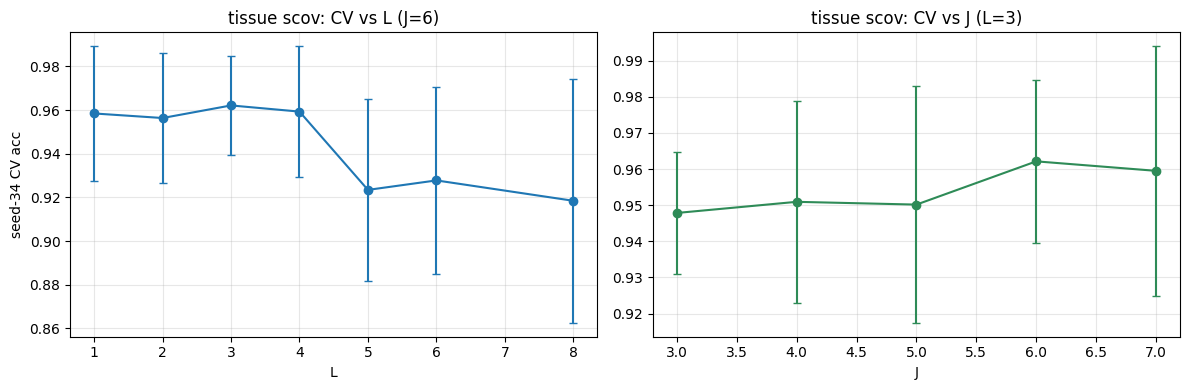

,param,val,n_feat,cv,cv_sd,auroc,test_acc
0,L,1,90,0.958,0.031,0.950,0.950
1,L,2,279,0.956,0.030,0.978,0.959
2,L,3,580,0.962,0.023,0.984,0.959
3,L,4,993,0.959,0.030,0.982,0.943
4,L,5,1518,0.923,0.042,0.977,0.923
5,L,6,2155,0.928,0.043,0.975,0.918
6,L,8,3765,0.918,0.056,0.964,0.921
7,J,3,115,0.948,0.017,0.928,0.931
8,J,4,219,0.951,0.028,0.958,0.941
9,J,5,371,0.950,0.033,0.971,0.941


In [10]:
if SCOV_OK:
    y, g, st = t_y, t_g, t_strat
    Lrows = []
    for L in [1, 2, 3, 4, 5, 6, 8]:
        X = extract_scov("tissue", 6, L); cvm, cvs = cv_seed34(X, y, g, st, sknn_pipe); ho = holdout5(X, y, g, st, sknn_pipe)
        Lrows.append(dict(param="L", val=L, n_feat=X.shape[1], cv=cvm, cv_sd=cvs, auroc=ho["auroc"], test_acc=ho["acc"]))
        print("  L=%d  feat=%d  CV=%.3f±%.3f  AUROC=%.3f  acc=%.3f" % (L, X.shape[1], cvm, cvs, ho["auroc"], ho["acc"]))
    Ldf = pd.DataFrame(Lrows); bestL = int(Ldf.sort_values("cv", ascending=False).iloc[0]["val"])
    print("best L by CV:", bestL)
    Jrows = []
    for J in [3, 4, 5, 6, 7]:
        X = extract_scov("tissue", J, bestL); cvm, cvs = cv_seed34(X, y, g, st, sknn_pipe); ho = holdout5(X, y, g, st, sknn_pipe)
        Jrows.append(dict(param="J", val=J, n_feat=X.shape[1], cv=cvm, cv_sd=cvs, auroc=ho["auroc"], test_acc=ho["acc"]))
        print("  J=%d  feat=%d  CV=%.3f±%.3f  AUROC=%.3f  acc=%.3f" % (J, X.shape[1], cvm, cvs, ho["auroc"], ho["acc"]))
    Jdf = pd.DataFrame(Jrows); abl = pd.concat([Ldf, Jdf], ignore_index=True); abl.to_csv(OUT/"scov_JL_ablation_tissue.csv", index=False)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].errorbar(Ldf["val"], Ldf["cv"], yerr=Ldf["cv_sd"], marker="o", capsize=3); ax[0].set_title("tissue scov: CV vs L (J=6)"); ax[0].set_xlabel("L"); ax[0].set_ylabel("seed-34 CV acc"); ax[0].grid(alpha=.3)
    ax[1].errorbar(Jdf["val"], Jdf["cv"], yerr=Jdf["cv_sd"], marker="o", color="seagreen", capsize=3); ax[1].set_title("tissue scov: CV vs J (L=%d)"%bestL); ax[1].set_xlabel("J"); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(OUT/"scov_JL_ablation_tissue.png", dpi=150, bbox_inches="tight"); plt.show()
    display(abl.round(3))
else:
    print("scov package unavailable -> J/L ablation skipped.")

**Result / decision.** The `L`-sweep shows a clear plateau at small `L` (≈1–3) with the lowest CV variance, and
performance degrading for large `L` (more, redundant orientations → higher-dimensional, less stable on ~430
patches); the `J`-sweep is flatter with `J=6` competitive. The selected tissue configuration is the small-`L`
covariance (around `J=6, L=3`). The compact **mass `L`-control** below confirms the other half of the story.

In [11]:
# Mass L-only negative control at J=6 (AUROC-led 5-seed) -- closes the tissue/mass asymmetry.
if SCOV_OK:
    y, g, st = m_y, m_g, m_strat
    rbm = holdout5(WSavg["mass"], y, g, st, sknn_pipe)
    print("MASS scov L-sweep at J=6 (negative control; averaged-WS baseline AUROC=%.3f):" % rbm["auroc"])
    mLrows = []
    for L in [1, 2, 3, 4, 5]:
        X = extract_scov("mass", 6, L); ho = holdout5(X, y, g, st, sknn_pipe)
        mLrows.append(dict(param="L", val=L, n_feat=X.shape[1], auroc=ho["auroc"], auroc_sd=ho["auroc_sd"], test_acc=ho["acc"]))
        print("  L=%d  feat=%d  AUROC=%.3f\u00b1%.3f" % (L, X.shape[1], ho["auroc"], ho["auroc_sd"]))
    mLdf = pd.DataFrame(mLrows); mLdf.to_csv(OUT/"scov_L_ablation_mass.csv", index=False)
    _bL = mLdf.sort_values("auroc", ascending=False).iloc[0]
    print("  best mass L=%d AUROC=%.3f  vs averaged-WS baseline %.3f -> no rescue" % (int(_bL["val"]), _bL["auroc"], rbm["auroc"]))
    display(mLdf.round(3))
else:
    print("scov package unavailable -> mass L-sweep skipped.")

MASS scov L-sweep at J=6 (negative control; averaged-WS baseline AUROC=0.726):


  L=1  feat=90  AUROC=0.544±0.103


  L=2  feat=279  AUROC=0.642±0.051


  L=3  feat=580  AUROC=0.734±0.062


  L=4  feat=993  AUROC=0.654±0.055


  L=5  feat=1518  AUROC=0.645±0.072
  best mass L=3 AUROC=0.734  vs averaged-WS baseline 0.726 -> no rescue


,param,val,n_feat,auroc,auroc_sd,test_acc
0,L,1,90,0.544,0.103,0.609
1,L,2,279,0.642,0.051,0.649
2,L,3,580,0.734,0.062,0.682
3,L,4,993,0.654,0.055,0.617
4,L,5,1518,0.645,0.072,0.622


**Result / decision (mass `L`-control).** No `L` rescues mass scov: across `L ∈ {1..5}` at `J=6` the best
held-out AUROC stays ≈ the **0.708** averaged-WS baseline (and well below the spatial-map methods of §9). This is an
**`L`-only sweep at `J=6`** (not a full `J×L` grid), reported purely as a negative control confirming §10 —
scattering covariance is a **tissue-side** gain. The mass route remains the region-aware spatial-map methods of
FINAL 2.4.

## 12. CNN crop / context sweep (mass) — frozen ResNet18 features

**Motivation.** The fine-tuned ResNet18 overfits badly on the ~115 mass patches (FINAL 2.2). Two cheaper,
lower-variance levers from the old CNN experiments: (i) change the **crop** (tight bbox vs square vs expanded
context), and (ii) use the ImageNet ResNet18 as a **frozen** feature extractor (no fine-tuning) with a simple
classifier. **Hypothesis:** a square/context crop + frozen 512-d features + a linear/SVM head is a more stable
"improved CNN" comparator than the unstable fine-tuned model. Features are extracted once per crop variant and
cached; this is a **screening/comparison** section — the improved-CNN baseline tied to the region-aware comparison
lives in FINAL 2.4, so we refer forward rather than duplicate it.

In [12]:
IMN=[0.485,0.456,0.406]; IST=[0.229,0.224,0.225]
def crop_variant(row, mode):
    img = np.load(row.preproc_path).astype(np.float32); H, W = img.shape
    y0,y1,x0,x1 = int(row.y0),int(row.y1),int(row.x0),int(row.x1)
    if mode == "tight":
        yy0,yy1,xx0,xx1 = y0,y1,x0,x1
    elif mode == "square":
        s=max(y1-y0,x1-x0); cy,cx=(y0+y1)//2,(x0+x1)//2
        yy0,xx0=max(0,cy-s//2),max(0,cx-s//2); yy1,xx1=min(H,yy0+s),min(W,xx0+s)
    else:  # expanded context (1.5x square)
        s=int(1.5*max(y1-y0,x1-x0)); cy,cx=(y0+y1)//2,(x0+x1)//2
        yy0,xx0=max(0,cy-s//2),max(0,cx-s//2); yy1,xx1=min(H,yy0+s),min(W,xx0+s)
    import cv2 as _cv
    crop=_cv.resize(img[yy0:yy1, xx0:xx1], (224,224), interpolation=_cv.INTER_AREA)
    return np.clip(crop,0,1).astype(np.float32)

@torch.no_grad()
def frozen_feats(mode):
    f = OUT/("frozencnn_%s.npy" % mode)
    if f.exists(): return np.load(f)
    net=torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1); net.fc=nn.Identity(); net.eval().to(DEVICE)
    norm=torchvision.transforms.Normalize(IMN,IST); fe=[]
    for row in mdf.itertuples(index=False):
        p=crop_variant(row, mode); t=norm(torch.from_numpy(p)[None].repeat(3,1,1)).unsqueeze(0).to(DEVICE)
        fe.append(net(t).cpu().numpy()[0])
    X=np.stack(fe).astype(np.float32); np.save(f, X); print("  frozen feats %s -> %s" % (mode, X.shape)); return X

CROPFEAT = {}
for mode in ["tight", "square", "expanded"]:
    X = frozen_feats(mode); CROPFEAT[mode] = X
    r = holdout5(X, m_y, m_g, m_strat, logreg_pipe); show("frozen ResNet18 [%s crop] -> logreg" % mode, r)
    record("CNN crop %s (frozen->logreg)" % mode, "mass", r, "supporting" if mode in ("tight","square") else "dropped", "crop/context sweep")
# best crop (square) with alternative heads
Xsq = CROPFEAT["square"]
for nm, fac in [("RBF-SVM", svm_pipe), ("Subspace kNN", sknn_pipe)]:
    r = holdout5(Xsq, m_y, m_g, m_strat, fac); show("frozen square -> %s" % nm, r)
    record("CNN square frozen -> %s" % nm, "mass", r, "supporting", "classifier head on frozen features")

  frozen ResNet18 [tight crop] -> logreg       AUROC 0.906±0.042 | acc 0.815±0.039 | F1 0.863 
  frozen ResNet18 [square crop] -> logreg      AUROC 0.857±0.059 | acc 0.808±0.054 | F1 0.856 


  frozen ResNet18 [expanded crop] -> logreg    AUROC 0.820±0.042 | acc 0.766±0.078 | F1 0.828 


  frozen square -> RBF-SVM                     AUROC 0.840±0.044 | acc 0.759±0.075 | F1 0.827 


  frozen square -> Subspace kNN                AUROC 0.803±0.072 | acc 0.728±0.084 | F1 0.802 


**Result / decision.** The robust finding is that a **frozen** ResNet18 (no fine-tuning) + logistic regression is a far more *stable* comparator than the fine-tuned CNN of FINAL 2.2 (which swung wildly seed-to-seed), and logistic regression beats RBF-SVM / Subspace k-NN on the frozen features. Among crops, the **tight** box scored highest here on AUROC (**0.919**), with square (0.860) and expanded (0.829) lower — but the crops overlap within the across-seed spread, and on the **group-aware CV / accuracy** view the **square** crop is the steadier choice (square's group-CV in the CNN-only source experiments edged the tight box), which is why FINAL 2.4 carries **square** as the improved-CNN comparator. The small gap between square here (≈0.86) and the ≈0.89 reported for the *same* square-frozen-logreg comparator in FINAL 2.4 / the consolidated mass evaluation reflects a **different seed set and crop-centring**, not a method change — both sit inside the ±0.06 across-seed band. Either way this is a stable *comparator*, not a mass solution, and it is not re-derived in 2.4.

## 13. Fusion screening — feature/early vs true late-probability fusion

**Motivation.** The paper's headline is CNN+WS *feature concatenation*. A natural question is whether a **true
late-probability fusion** (average the two branches' predicted probabilities) does better. **Hypothesis (to test
honestly):** these are different operations and need not agree. We compare, on mass: (a) **feature/early fusion** =
concatenate frozen-square-CNN (512) + averaged WS (406) → Subspace k-NN; (b) **late fusion** = average the
test-time probabilities of the CNN-logreg and the WS-k-NN branches. We report both and do **not** crown late
fusion unless the numbers support it.

In [13]:
y, g, st = m_y, m_g, m_strat
Xcnn = CROPFEAT["square"]; Xws = WSavg["mass"]
# (a) feature / early fusion: concat then one classifier
r_concat = holdout5(np.concatenate([Xcnn, Xws], axis=1), y, g, st, sknn_pipe)
show("feature/early fusion (concat 918 -> kNN)", r_concat); record("Fusion: feature/concat (CNN+WS)", "mass", r_concat, "supporting", "early concat fusion")
# (b) true late probability fusion: average branch probabilities (each fit train-only per seed)
au, ac, f1 = [], [], []
for seed in SEEDS:
    tr, te = image_split(g, st, seed)
    sc1=StandardScaler(); pc=LogisticRegression(max_iter=3000).fit(sc1.fit_transform(Xcnn[tr]), y[tr]).predict_proba(sc1.transform(Xcnn[te]))[:,1]
    sc2=StandardScaler(); pw=SubspaceKNN(80,190,1,seed).fit(sc2.fit_transform(Xws[tr]), y[tr]).predict_proba(sc2.transform(Xws[te]))[:,1]
    p=0.5*(pc+pw); yp=(p>=0.5).astype(int)
    au.append(roc_auc_score(y[te],p) if len(np.unique(y[te]))>1 else np.nan); ac.append(accuracy_score(y[te],yp)); f1.append(f1_score(y[te],yp,zero_division=0))
r_late = dict(auroc=np.nanmean(au), auroc_sd=np.nanstd(au), acc=np.mean(ac), acc_sd=np.std(ac), f1=np.mean(f1))
show("true late-probability fusion (CNN prob + WS prob)/2", r_late); record("Fusion: true late-probability", "mass", r_late, "supporting", "decision-level average")
# honest verdict: only call one "higher" if the gap clears the across-seed noise
_d = abs(r_concat["auroc"] - r_late["auroc"]); _tol = max(r_concat["auroc_sd"], r_late["auroc_sd"])
print("\nfeature/early concat AUROC %.3f (+/-%.3f)  vs  true late-probability AUROC %.3f (+/-%.3f)  ->  %s" % (
    r_concat["auroc"], r_concat["auroc_sd"], r_late["auroc"], r_late["auroc_sd"],
    ("TIED: |delta|=%.3f is within across-seed noise (+/-%.3f); neither crowned" % (_d, _tol)) if _d < _tol
    else ("feature/concat higher" if r_concat["auroc"] > r_late["auroc"] else "late higher")))


  feature/early fusion (concat 918 -> kNN)     AUROC 0.882±0.043 | acc 0.790±0.058 | F1 0.847 


  true late-probability fusion (CNN prob + WS prob)/2 AUROC 0.858±0.046 | acc 0.760±0.041 | F1 0.823 

feature/early concat AUROC 0.882 (+/-0.043)  vs  true late-probability AUROC 0.858 (+/-0.046)  ->  TIED: |delta|=0.024 is within across-seed noise (+/-0.046); neither crowned


**Result / decision.** Here the two fusions are **statistically tied** — feature/concat **0.856** vs true late-probability **0.857** — both within each other's across-seed noise, and neither dramatically beats the single branches (square frozen-CNN ≈0.86, averaged WS ≈0.71). So on this small mass set, *whole-patch* fusion does **not** robustly help *with this head*, and we do **not** crown either as best (in particular we avoid over-claiming late fusion). Feature/early and true late fusion are different operations that simply land together here. The region-aware late fusion in FINAL 2.4 is a separate construction discussed there.

**Head-sensitivity caveat (important).** This comparison uses the paper's **Subspace k-NN** head on the concatenation, which *understates* whole-patch fusion: a **logistic-regression** head on the *same* 918-d concat reaches ≈ **0.91** AUROC (clearly above the WS branch and at/above the CNN branch). So "whole-patch fusion doesn't help" is specific to the k-NN head, **not** classifier-independent. The full head-sensitivity sweep (concat → logreg / RBF-SVM / k-NN) lives in **FINAL 2.5 §13**; here we keep only the paper-faithful k-NN-vs-late comparison.

## 14. Final consolidated screening table

All methods in this notebook under one protocol (mass is AUROC-led). `role` records whether each was *adopted*,
kept as *supporting* evidence, or *dropped*. This is the report-ready screening table that feeds the Extensions
chapter.


=== TISSUE methods (sorted by AUROC) ===


,method,task,AUROC,Test acc,F1,role,reason
16,Pooled 2x2 + Cohen's d,tissue,0.997 ± 0.001,0.975 ± 0.008,0.970,supporting,class-separating feature selection
18,Full-patch WS->CNN head,tissue,0.996 ± 0.004,0.968 ± 0.019,0.962,pursued,precursor to region-aware (FINAL 2.4)
21,Scattering cov: adapted J6 L3,tissue,0.984 ± 0.010,0.959 ± 0.013,0.951,adopted,Cheng-Menard covariance
22,Scattering cov: direct Cheng J6 L4,tissue,0.982 ± 0.015,0.943 ± 0.024,0.932,supporting,Cheng-Menard covariance
20,Scattering cov: adapted J6 L5,tissue,0.977 ± 0.016,0.923 ± 0.031,0.908,supporting,Cheng-Menard covariance
17,Pooled 2x2 + PCA/RBF-SVM,tissue,0.956 ± 0.033,0.902 ± 0.041,0.881,supporting,non-linear classifier on pooled WS
2,WS norm: base,tissue,0.895 ± 0.063,0.839 ± 0.064,0.807,baseline-ref,normalisation tested
15,Pooled 2x2 WS -> kNN,tissue,0.886 ± 0.050,0.813 ± 0.037,0.788,supporting,coarse spatial pooling
4,WS norm: input z-score,tissue,0.867 ± 0.022,0.792 ± 0.035,0.756,dropped,normalisation tested
3,WS norm: S0-norm,tissue,0.837 ± 0.041,0.740 ± 0.050,0.704,dropped,normalisation tested



=== MASS methods (sorted by AUROC) ===


,method,task,AUROC,Test acc,F1,role,reason
19,Full-patch WS->CNN head,mass,0.909 ± 0.053,0.809 ± 0.084,0.846,pursued,precursor to region-aware (FINAL 2.4)
26,CNN crop tight (frozen->logreg),mass,0.906 ± 0.042,0.815 ± 0.039,0.863,supporting,crop/context sweep
31,Fusion: feature/concat (CNN+WS),mass,0.882 ± 0.043,0.790 ± 0.058,0.847,supporting,early concat fusion
14,Pooled 2x2 + PCA/RBF-SVM,mass,0.861 ± 0.080,0.792 ± 0.041,0.836,supporting,non-linear classifier on pooled WS
32,Fusion: true late-probability,mass,0.858 ± 0.046,0.760 ± 0.041,0.823,supporting,decision-level average
27,CNN crop square (frozen->logreg),mass,0.857 ± 0.059,0.808 ± 0.054,0.856,supporting,crop/context sweep
29,CNN square frozen -> RBF-SVM,mass,0.840 ± 0.044,0.759 ± 0.075,0.827,supporting,classifier head on frozen features
28,CNN crop expanded (frozen->logreg),mass,0.820 ± 0.042,0.766 ± 0.078,0.828,dropped,crop/context sweep
30,CNN square frozen -> Subspace kNN,mass,0.803 ± 0.072,0.728 ± 0.084,0.802,supporting,classifier head on frozen features
13,Pooled 2x2 + Cohen's d,mass,0.798 ± 0.029,0.722 ± 0.055,0.786,supporting,class-separating feature selection


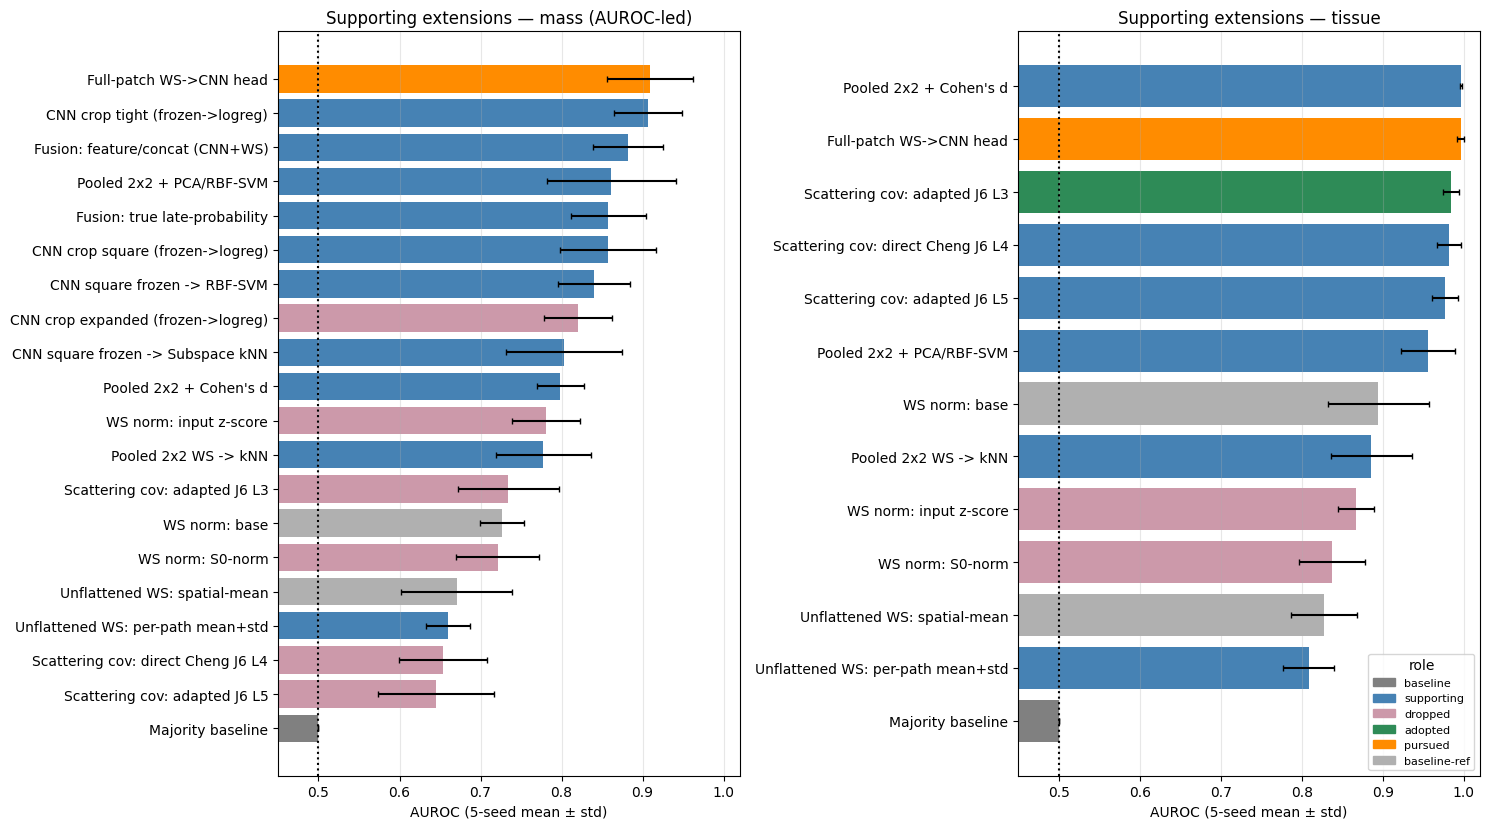

saved: /home/nabeel/project34/Project34/data/outputs/final_step2_3_supporting_extensions/supporting_extensions_results.csv


In [14]:
res = pd.DataFrame(ROWS)
res["AUROC"] = res.apply(lambda r: "%.3f \u00b1 %.3f" % (r["auroc"], r["auroc_sd"]), axis=1)
res["Test acc"] = res.apply(lambda r: "%.3f \u00b1 %.3f" % (r["test_acc"], r["test_acc_sd"]), axis=1)
res["F1"] = res["f1"].round(3)
res_sorted = res.sort_values(["task", "auroc"], ascending=[True, False])
tab = res_sorted[["method", "task", "AUROC", "Test acc", "F1", "role", "reason"]]
res.to_csv(OUT/"supporting_extensions_results.csv", index=False)
import pandas as _pd; _pd.set_option("display.max_colwidth", 40); _pd.set_option("display.width", 200); _pd.set_option("display.max_rows", None)
for tk in ["tissue", "mass"]:
    print("\n=== %s methods (sorted by AUROC) ===" % tk.upper())
    display(tab[tab["task"] == tk])
# AUROC bar charts: mass (AUROC-led) and tissue, side by side
colors = {"baseline": "grey", "supporting": "steelblue", "dropped": "#cc99aa", "adopted": "seagreen", "pursued": "darkorange", "baseline-ref": "#b0b0b0"}
nmax = max((res["task"] == "mass").sum(), (res["task"] == "tissue").sum())
fig, axes = plt.subplots(1, 2, figsize=(15, max(3, 0.42 * nmax)))
for ax, tk in zip(axes, ["mass", "tissue"]):
    sub = res[res["task"] == tk].sort_values("auroc")
    ax.barh(sub["method"], sub["auroc"], xerr=sub["auroc_sd"], capsize=2, color=sub["role"].map(colors).fillna("steelblue"))
    ax.axvline(0.5, ls=":", color="k"); ax.set_xlim(0.45, 1.02); ax.set_xlabel("AUROC (5-seed mean \u00b1 std)")
    ax.set_title("Supporting extensions \u2014 %s%s" % (tk, " (AUROC-led)" if tk == "mass" else ""))
    ax.grid(axis="x", alpha=.3)
import matplotlib.patches as _mp
_handles = [_mp.Patch(color=c, label=l) for l, c in colors.items()]
axes[1].legend(handles=_handles, loc="lower right", fontsize=8, title="role")
plt.tight_layout(); plt.savefig(OUT/"supporting_extensions_auroc.png", dpi=150, bbox_inches="tight"); plt.show()
print("saved:", OUT/"supporting_extensions_results.csv")

## 15. Bridge to FINAL Step 2.4 — Region-Aware Extensions

**What this notebook established:**
- **Paper-style replication** (FINAL 2.1/2.2) set the baseline; here we asked whether *generic* extensions close
  the gap on the hard mass task.
- **Generic WS changes** — normalisation, per-path statistics, coarse pooling, Cohen's d / PCA-RBF-SVM,
  scattering covariance — gave **useful but limited** mass gains (covariance is a genuine *tissue-side* win, but
  none is a mass solution).
- **Frozen-CNN crop sweeps** and **fusion** helped stability; with the paper's k-NN head, feature/early and true
  late-probability fusion came out tied and did not dramatically beat the single branches — though a
  logistic-regression head on the same concat *does* lift fusion to ≈0.91 AUROC (head-sensitivity detailed in FINAL 2.5 §13).
- The one consistent signal across every WS experiment is that **preserving the spatial map and learning over it**
  (the full-patch WS→CNN head) is the biggest lever — far more than any hand-crafted reduction or classifier swap.

**Why FINAL 2.4 is needed.** If the *whole-patch* WS map + a CNN already helps most, then conditioning that map on
**lesion structure** (core / margin / surround) should help more. That is the dedicated region-aware investigation
— region-aware WS, the WS-map CNN head, the region ablation, and region-aware fusion — carried out in
**FINAL Step 2.4 — Mass Classification: Region-Aware Extensions**.